

<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Certification Project Statement - FMCG </h2>
</div>

<div class="alert alert-info" style="background-color:#001b92; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


- New DG Food Agro are a multinational exporter of various grains from India since nearly 130 years. 
- But their main product of exporting since early 1980s has been Wheat. 
- They export wheat to countries like America, Afghanistan, Australia etc. 
- They started seeing varying exports of sales year on year for various countries. 
- The reason that was theorized by them had a lot of natural causes like floods, country growth, population explosion etc.
- Now they need to decide which countries fall in the same range of export and which don’t. 
- They also need to know which countries export is low and can be improved and which countries are performing very well across the years.The data provided right now is across 18 years. 
- What they need is a repeatable solution which won’t get affected no matter how much data is added across time and that they should be able to explain the data across years in less number of variables. 

## Objective: 
- Our objective is to cluster the countries based on various sales data provided to us across years. 
- We have to apply an unsupervised learning technique like K means or Hierarchical clustering so as to get the final solution. 
- But before that we have to bring the exports (in tons) of all countries down to same scale across years. 
- Plus, as this solution needs to be repeatable we will have to do PCA so as to get the principal components which explain max variance. 


## Implementation:
- 1)Read the data file and check for any missing values
- 2)Change the headers to country and year accordingly.
- 3)Cleanse the data if required and remove null or blank values
- 4)After the EDA part is done, try to think which algorithm should be applied here.
- 5)As we need to make this across years we need to apply PCA first.
- 6)Apply PCA on the dataset and find the number of principal components which explain nearly all the variance.
- 7)Plot elbow chart or scree plot to find out optimal number of clusters. 
- 8)Then try to apply K means, Hierarchicalclustering and showcase the results.  
- 9)You can either choose to group the countries based on years of data or using the principal components.
- 10)Then see which countries are consistent and which are largest importers of the good based on scale and position of cluster.


##  1. Import all Library

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data load, used thousands = ',' to convert , in data to normal integer
fmcg = pd.read_csv(r'..\CTS_2_FMCG\Dataset\Project_Data_1.csv'
                 , thousands = ',' )

print(fmcg[fmcg['Sales of Wheat in tons']=='Djibouti'])
fmcg.head()

   Sales of Wheat in tons  1990  1991  1992  1993  1994  1995  1996  1997  \
54               Djibouti  1485  1477  1463  1442  1414  1381   720   669   

    1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  
54   698   701   761   775   932   960  1034  1046  1093  1104  


,Sales of Wheat in tons,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
0,Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238
1,Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22
2,Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56
3,American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5
4,Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19


## 2. EDA- Data wrangling

##### Cleanse the data if required and remove null or blank values

**  Check for any missing values

In [76]:
fmcg.isnull().sum()

Sales of Wheat in tons    0
1990                      0
1991                      0
1992                      0
1993                      0
1994                      0
1995                      0
1996                      0
1997                      0
1998                      0
1999                      0
2000                      0
2001                      0
2002                      0
2003                      0
2004                      0
2005                      0
2006                      0
2007                      0
dtype: int64

In [77]:
fmcg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 19 columns):
Sales of Wheat in tons    207 non-null object
1990                      207 non-null int64
1991                      207 non-null int64
1992                      207 non-null int64
1993                      207 non-null int64
1994                      207 non-null int64
1995                      207 non-null int64
1996                      207 non-null int64
1997                      207 non-null int64
1998                      207 non-null int64
1999                      207 non-null int64
2000                      207 non-null int64
2001                      207 non-null int64
2002                      207 non-null int64
2003                      207 non-null int64
2004                      207 non-null int64
2005                      207 non-null int64
2006                      207 non-null int64
2007                      207 non-null int64
dtypes: int64(18), object(1)
memory usa

- No missing values , no null values in dataset

### 2.1 Change the headers to country and year accordingly.

In [78]:
fmcg = fmcg.rename(columns={"Sales of Wheat in tons":"country"})
fmcg.set_index('country', inplace= True)
fmcg.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
country,,,,,,,,,,,,,,,,,,
Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238
Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22
Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56
American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5
Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19


In [79]:
"""fmcg = fmcg.rename(columns={"1990":"year_90", "1991":"year_91", "1992":"year_92", "1993":"year_93", "1994":"year_94","1995":"year_95"
                         , "1996":"year_96", "1997":"year_97", "1998":"year_98","1999":"year_99", "2000":"year_00", "2001":"year_01", "2002":"year_02",  
                            "2003":"year_03", "2004":"year_04", "2005":"year_05", "2006":"year_06", "2007":"year_07",})
    

"""
fmcg.columns.names = ['years']
fmcg.head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
country,,,,,,,,,,,,,,,,,,
Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238
Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22
Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56
American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5
Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19


## 3. After the EDA part is done, try to think which algorithm should be applied here.

- Data dont have any labelled o/p so we should go with unsupervised learning. Either K-Mean cluster or Hirarchical cluster

##### - 5) As we need to make this across years we need to apply PCA first.
##### - 6) Apply PCA on the dataset and find the number of principal components which explain nearly all the variance.

### 3.1 Before PCA, we will scale the data


In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(fmcg)
#transform 
fmcg_scaled_data = scaler.transform(fmcg)
fmcg_scaled_data[0:1,0:]  # 1 row all 18 col

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  """


array([[1.03110452, 1.01641938, 1.02196785, 1.01942307, 1.00947772,
        0.98629122, 1.12819983, 1.07411977, 1.0397738 , 0.98938988,
        0.84681087, 0.72433088, 0.60775318, 0.627344  , 0.51947036,
        0.45473638, 0.38936941, 0.33411829]])

### 3.2 Apply PCA

In [81]:
# Implementing the PCA and resducing the number of columns
from sklearn.decomposition import PCA

for i in range(1,7):
    pca_model = PCA(n_components=i)
    pca_model.fit(fmcg_scaled_data)

    # transform the data from multidimension to 2D
    data_2d = pca_model.transform(fmcg_scaled_data)
    data_df_2d = pd.DataFrame(data_2d)
    a = pca_model.explained_variance_ratio_
    print("n component = %s total varience is %s " %( i, a.sum()))


n component = 1 total varience is 0.9203977111052274 
n component = 2 total varience is 0.9774467406727502 
n component = 3 total varience is 0.9890913377645849 
n component = 4 total varience is 0.991625818376694 
n component = 5 total varience is 0.993924698071278 
n component = 6 total varience is 0.9955243535612756 


#### By looking above o/p n_component =4 will give better 99.16 varience
- So we will apply PCA for 4 component

In [82]:
pca_model = PCA(n_components=4)
pca_model.fit(fmcg_scaled_data)

# transform the data from multidimension to 2D
fmcg_4d = pca_model.transform(fmcg_scaled_data)
fmcg_4d_pca = pd.DataFrame(fmcg_4d)
a = pca_model.explained_variance_ratio_

# do some formatting, assign index value and column name to pca dataset
fmcg_4d_pca.index = fmcg.index
fmcg_4d_pca.columns = ['PC1', 'PC2', 'PC3', 'PC4']


print(a.sum())
fmcg_4d_pca.head()

0.991625818376694


,PC1,PC2,PC3,PC4
country,,,,
Afghanistan,3.498735,0.975856,-0.438339,0.015607
Albania,-2.936103,0.012171,0.016047,-0.028113
Algeria,-2.725665,-0.185039,0.107767,-0.030382
American Samoa,-3.445596,0.005623,0.136492,-0.053546
Andorra,-3.181315,0.033922,0.129368,-0.021619


## 4 Apply Unsupervised learning
##### - 7) Plot elbow chart or scree plot to find out optimal number of clusters. 

In [83]:
#To provide all 4 values in array
X = fmcg_4d_pca.values
X

array([[ 3.49873511e+00,  9.75855643e-01, -4.38338942e-01,
         1.56072481e-02],
       [-2.93610256e+00,  1.21707789e-02,  1.60467956e-02,
        -2.81132747e-02],
       [-2.72566479e+00, -1.85039374e-01,  1.07766864e-01,
        -3.03824873e-02],
       [-3.44559577e+00,  5.62296548e-03,  1.36491727e-01,
        -5.35459160e-02],
       [-3.18131500e+00,  3.39216419e-02,  1.29368051e-01,
        -2.16193476e-02],
       [ 4.70700832e+00,  1.40169630e+00, -3.03976710e-01,
        -2.88797443e-01],
       [-2.96597350e+00, -8.13283584e-02,  8.73195308e-02,
        -2.55404260e-02],
       [-3.47233611e+00, -4.20098024e-02,  1.19091231e-01,
        -3.13110890e-02],
       [-2.45324611e+00,  2.70218442e-01,  7.39916778e-02,
        -3.53926784e-02],
       [-2.15013162e+00, -3.70258662e-01, -7.24425249e-02,
         4.70244850e-03],
       [-3.55999540e+00, -8.05536253e-02,  1.10766602e-01,
        -2.64724108e-02],
       [-3.43476117e+00, -4.48405610e-02,  1.13908790e-01,
      

### 4.1 Elbow Curve For K value

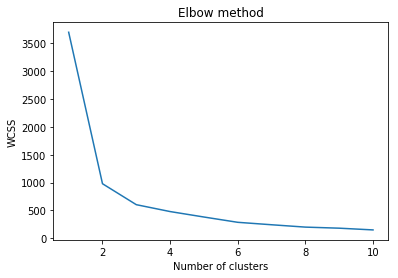

In [84]:
# using elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans

wcss = []  # within cluster square of sums or inertia

for i in range(1,11):
    #n_init:default=10 It is the no. of times the KMeans algorithm will be run with different initial centroid.
    kmeans_model = KMeans(n_clusters=i, init='k-means++',
                         n_init=10, random_state=42)
    #train the model
    kmeans_model.fit(X)
    wcss.append(kmeans_model.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

#### By above elbow graph, looks like elbow in K=3, which has maximum angle
- No of cluster/ Optimal no of cluster =3


### 4.2 KMEAN CLUSTER

##### - 8) Then try to apply K means, Hierarchical clustering and showcase the results.  

In [85]:
from sklearn.cluster import KMeans

kmean = KMeans(n_clusters=3, init='k-means++')
y_means = kmean.fit_predict(X)
y_means  # cluster IDs from 0 to 2
#y_means : cluster numbers which input data belongs to

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 2, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 1, 0, 2, 0, 0,
       0, 0, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 2, 1])

In [86]:
#Centroid
centroid = kmean.cluster_centers_
centroid

array([[-2.47393975e+00,  5.33076830e-02,  3.54465256e-02,
        -8.02722772e-04],
       [ 3.94539763e+00, -3.54111633e-01, -1.22706456e-01,
         2.57922484e-02],
       [ 9.47222647e+00,  6.36824898e-01,  7.10851669e-02,
        -7.35267818e-02]])

** Check the lables of data point
  - Check the size of labels -- should match dataset count 
  - The cluster labels are returned in `kmeans.labels_`. 

In [87]:
print (kmean.labels_)
print (len(kmean.labels_))
print (len(X))

[1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 1 0 1 0 0 0 0 1 1 2 0 0 1 0
 1 1 0 1 0 0 1 0 0 0 0 0 0 1 2 1 0 2 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 0
 0 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 2 0 0 1 0 0 1 1 0 0 0 1 1 0 0
 2 0 2 0 0 0 0 1 0 0 1 1 2 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 2 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 1 0 2 0 0 0 1 1 2 0 0 1 0 2 0 0 0 0 1 0 2 2 0 0 0
 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 2 1]
207
207


### 4.3 Append Cluster no to Original Data

In [88]:
## How many countries are there in 1st and 2nd cluster

print (type(kmean.labels_))
# This gives each cluster and its unique datapoints or all ountry count
unique, counts = np.unique(kmean.labels_, return_counts=True)
print(unique)
print(counts)
print("\n No of countries in each cluster:")
print(dict(zip(unique, counts)))

new_dict = dict(zip(unique, counts))
new_dict[0]

<class 'numpy.ndarray'>
[0 1 2]
[141  50  16]

 No of countries in each cluster:
{0: 141, 1: 50, 2: 16}


141

### 4.4 Conclusion:  
    - 0th  cluster has 50 Countries, 1st cluster has 141 countries and 2nd has 16 countrie


## 5. Plot The graph 

- Based on cluster id to give color


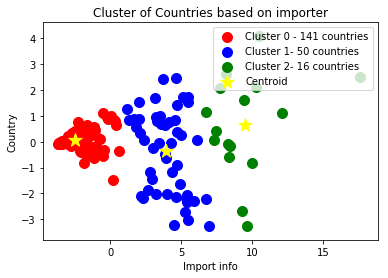

In [89]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1],
           s=100, c='red', label='Cluster 0 - %d countries' %new_dict[0])
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1],
           s=100, c='blue', label='Cluster 1- %d countries' %new_dict[1])
plt.scatter(X[y_means == 2, 0], X[y_means ==2, 1],
           s=100, c='green', label='Cluster 2- %d countries' %new_dict[2])

#Centroid
plt.scatter(centroid[:,0], centroid[:,1], s=200, c='yellow', label='Centroid',marker ='*')

plt.title("Cluster of Countries based on importer")
plt.xlabel("Import info")
plt.ylabel("Country")
plt.legend(loc='upper right')
plt.show()

### By this we can group like below
- all cluster =0 /Label=0 as low import related countries (Red)
- all cluster =1 /Label=1 as medium import related countries (Blue)
- all cluster =2 /Label=2 as High import related countries (Green)

### 5.1 Append label_/ predicted o/p to input dataset to see country and yearwise each country belongs to which cluster/Group

#### Conclusion
- all cluster =0 /Label=0 as low import related countries (Red)
- all cluster =1 /Label=1 as medium import related countries (Blue)
- all cluster =2 /Label=2 as High import related countries (Green)


In [90]:
# Append o/p to PCA dataset
fmcg_4d_pca['cluster_knn'] = kmean.labels_
print(fmcg_4d_pca.head())

                     PC1       PC2       PC3       PC4  cluster_knn
country                                                            
Afghanistan     3.498735  0.975856 -0.438339  0.015607            1
Albania        -2.936103  0.012171  0.016047 -0.028113            0
Algeria        -2.725665 -0.185039  0.107767 -0.030382            0
American Samoa -3.445596  0.005623  0.136492 -0.053546            0
Andorra        -3.181315  0.033922  0.129368 -0.021619            0


In [91]:
# Append o/p to original dataset
fmcg['cluster_knn'] = kmean.labels_
fmcg['cluster_knn'] = fmcg['cluster_knn'].map({0:'Low',1:'Medium',2:'High'})
fmcg.head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn
country,,,,,,,,,,,,,,,,,,,
Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238,Medium
Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22,Low
Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56,Low
American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5,Low
Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19,Low


In [92]:
# High import related countries
fmcg[fmcg["cluster_knn"] == 'High'].head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn
country,,,,,,,,,,,,,,,,,,,
Bangladesh,639,623,608,594,579,576,550,535,516,492,500,491,478,458,444,416,392,387,High
Bhutan,924,862,804,750,699,651,620,597,551,538,515,512,472,460,443,412,406,363,High
Cambodia,928,905,881,858,836,811,810,789,777,764,758,750,728,712,696,676,672,664,High
"Korea, Dem. Rep.",841,828,815,802,788,775,775,775,775,770,713,650,577,527,499,508,500,441,High
Djibouti,1485,1477,1463,1442,1414,1381,720,669,698,701,761,775,932,960,1034,1046,1093,1104,High


In [93]:
# medium import related countries
fmcg[fmcg["cluster_knn"] == 'Medium'].head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn
country,,,,,,,,,,,,,,,,,,,
Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238,Medium
Angola,514,514,513,512,510,508,512,363,414,384,530,335,307,281,318,331,302,294,Medium
Bolivia,377,362,347,333,320,306,271,264,254,248,238,229,223,218,211,205,202,198,Medium
Botswana,344,355,351,349,347,349,336,349,371,413,445,497,535,586,598,599,621,622,Medium
Burkina Faso,179,196,208,221,233,246,251,271,286,308,338,368,398,419,426,421,411,403,Medium


In [94]:
# low  import related countries
fmcg[fmcg["cluster_knn"] == 'Low'].head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn
country,,,,,,,,,,,,,,,,,,,
Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22,Low
Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56,Low
American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5,Low
Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19,Low
Anguilla,38,38,37,37,36,35,35,36,36,36,35,35,35,35,35,34,34,34,Low


## 6. KNN algorithm conclusion:

- 9) You can either choose to group the countries based on years of data or using the principal components.
- 10) Then see which countries are consistent and which are largest importers of the good based on scale and position of cluster.

### Below we will see all country list based on its import range. Using this data FMCG can decide
*  Which countries fall in the same range of export and which don’t. 
* Which countries export is low and can be improved  
* which countries are performing very well across the years.

In [95]:
print(" Countries which have largest import which is performing well: \n" , fmcg[fmcg["cluster_knn"] == 'High'].index.values)

print("###"*10)
      
print("\n Countries which have Medium import : \n" , fmcg[fmcg["cluster_knn"] == 'Medium'].index.values)

print("###"*10)

print("\n Countries which have low import which can be improved : \n" , fmcg[fmcg["cluster_knn"] == 'Low'].index.values)
print("###"*10)

 Countries which have largest import which is performing well: 
 ['Bangladesh' 'Bhutan' 'Cambodia' 'Korea, Dem. Rep.' 'Djibouti' 'Kiribati'
 'Mali' 'Mauritania' 'Namibia' 'Philippines' 'Sierra Leone' 'South Africa'
 'Swaziland' 'Timor-Leste' 'Togo' 'Zambia']
##############################

 Countries which have Medium import : 
 ['Afghanistan' 'Angola' 'Bolivia' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cape Verde' 'Central African Republic' 'Chad' 'China' 'Congo, Rep.'
 "Cote d'Ivoire" 'Congo, Dem. Rep.' 'Equatorial Guinea' 'Ethiopia' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'India' 'Indonesia'
 'Kenya' 'Laos' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mongolia'
 'Mozambique' 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan'
 'Papua New Guinea' 'Peru' 'Rwanda' 'Sao Tome and Principe' 'Senegal'
 'Solomon Islands' 'Somalia' 'Sudan' 'Thailand' 'Tuvalu' 'Uganda'
 'Tanzania' 'Viet Nam' 'Zimbabwe']
##############################

 Countries which have low import which can be impr

## 7. Hierarchical clustering
#### Using  Hierarchical clustering and showcase the results.  

In [96]:
 #Use the pca data
from sklearn.cluster import AgglomerativeClustering
#hERE no of distinct unique 0/p value considered as n_clusters

cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')  
cluster.fit_predict(X)  

array([0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 0, 1, 0, 1, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 2, 0], dtype=int64)

In [97]:
 #After agglomerative algorithm labels/o/p
cluster.labels_


array([0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 0, 1, 0, 1, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 2, 0], dtype=int64)

In [98]:

# Append o/p to PCA dataset
fmcg_4d_pca['cluster_Hierarchy'] = cluster.labels_
print(fmcg_4d_pca.head())

                     PC1       PC2       PC3       PC4  cluster_knn  \
country                                                               
Afghanistan     3.498735  0.975856 -0.438339  0.015607            1   
Albania        -2.936103  0.012171  0.016047 -0.028113            0   
Algeria        -2.725665 -0.185039  0.107767 -0.030382            0   
American Samoa -3.445596  0.005623  0.136492 -0.053546            0   
Andorra        -3.181315  0.033922  0.129368 -0.021619            0   

                cluster_Hierarchy  
country                            
Afghanistan                     0  
Albania                         1  
Algeria                         1  
American Samoa                  1  
Andorra                         1  


In [99]:
# This gives each cluster and its unique datapoints or all ountry count
unique1, counts1 = np.unique(cluster.labels_, return_counts=True)
new_dict1 = dict(zip(unique1, counts1))

# This is Hierarchical gruoping
new_dict1

{0: 49, 1: 141, 2: 17}

In [100]:
# This is Kmean gruoping
new_dict

{0: 141, 1: 50, 2: 16}

### 7.1 Plot the Graph

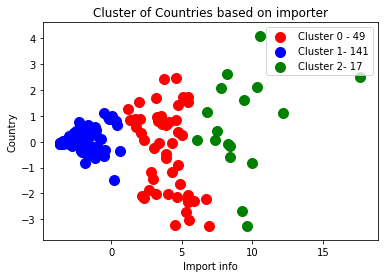

In [101]:
y_means_h =cluster.fit_predict(X)
#Plot the graph
plt.scatter(X[y_means_h == 0, 0], X[y_means_h == 0, 1],
           s=100, c='red', label='Cluster 0 - %d' %new_dict1[0])
plt.scatter(X[y_means_h == 1, 0], X[y_means_h == 1, 1],
           s=100, c='blue', label='Cluster 1- %d' %new_dict1[1])
plt.scatter(X[y_means_h == 2, 0], X[y_means_h ==2, 1],
           s=100, c='green', label='Cluster 2- %d' %new_dict1[2])

#Centroid
#plt.scatter(centroid[:,0], centroid[:,1], s=200, c='yellow', label='Centroid',marker ='*')

plt.title("Cluster of Countries based on importer")
plt.xlabel("Import info")
plt.ylabel("Country")
plt.legend()
plt.show()

### Based on this 
- all cluster =0 /Label=0 as Medium import related countries (Red)
- all cluster =1 /Label=1 as low import related countries (Blue)
- all cluster =2 /Label=2 as High import related countries (Green)

In [102]:
# Append o/p to original dataset
fmcg['cluster_Hierarchy'] = cluster.labels_
fmcg['cluster_Hierarchy'] = fmcg['cluster_Hierarchy'].map({0:'Medium',1:'Low',2:'High'})
fmcg.head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn,cluster_Hierarchy
country,,,,,,,,,,,,,,,,,,,,
Afghanistan,436,429,422,415,407,397,397,387,374,373,346,326,304,308,283,267,251,238,Medium,Medium
Albania,42,40,41,42,42,43,42,44,43,42,40,34,32,32,29,29,26,22,Low,Low
Algeria,45,44,44,43,43,42,43,44,45,46,48,49,50,51,52,53,55,56,Low,Low
American Samoa,42,14,4,18,17,22,0,25,12,8,8,6,5,6,9,11,9,5,Low,Low
Andorra,39,37,35,33,32,30,28,23,24,22,20,20,21,18,19,18,17,19,Low,Low


## 8. Compared KNN cluster result with Hierachy cluster result

- Only 1 country falling in different cluster, remaining all are in sync

In [103]:
fmcg[fmcg["cluster_knn"] != fmcg["cluster_Hierarchy"] ]

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,cluster_knn,cluster_Hierarchy
country,,,,,,,,,,,,,,,,,,,,
Papua New Guinea,498,498,497,497,496,496,494,493,491,489,486,482,477,471,463,453,441,430,Medium,High





## 9. FINAL CONCLUSION 

####  Countries which have largest import which is performing well: 
 ['Bangladesh' 'Bhutan' 'Cambodia' 'Korea, Dem. Rep.' 'Djibouti' 'Kiribati'
 'Mali' 'Mauritania' 'Namibia' 'Philippines' 'Sierra Leone' 'South Africa'
 'Swaziland' 'Timor-Leste' 'Togo' 'Zambia']


#### Countries which have Medium import : 
 ['Afghanistan' 'Angola' 'Bolivia' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cape Verde' 'Central African Republic' 'Chad' 'China' 'Congo, Rep.'
 "Cote d'Ivoire" 'Congo, Dem. Rep.' 'Equatorial Guinea' 'Ethiopia' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'India' 'Indonesia'
 'Kenya' 'Laos' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mongolia'
 'Mozambique' 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan'
 'Papua New Guinea' 'Peru' 'Rwanda' 'Sao Tome and Principe' 'Senegal'
 'Solomon Islands' 'Somalia' 'Sudan' 'Thailand' 'Tuvalu' 'Uganda'
 'Tanzania' 'Viet Nam' 'Zimbabwe']


#### Countries which have low import which can be improved : 
 ['Albania' 'Algeria' 'American Samoa' 'Andorra' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bermuda' 'Bosnia and Herzegovina' 'Brazil'
 'British Virgin Islands' 'Brunei Darussalam' 'Bulgaria' 'Cameroon'
 'Canada' 'Cayman Islands' 'Chile' 'Colombia' 'Comoros' 'Cook Islands'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic' 'Denmark'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Fiji' 'Finland' 'France' 'French Polynesia' 'Georgia'
 'Germany' 'Greece' 'Grenada' 'Guam' 'Guatemala' 'Guyana' 'Honduras'
 'Hungary' 'Iceland' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kazakhstan' 'Kuwait' 'Kyrgyzstan' 'Latvia' 'Lebanon'
 'Libyan Arab Jamahiriya' 'Lithuania' 'Luxembourg' 'Malaysia' 'Maldives'
 'Malta' 'Mauritius' 'Mexico' 'Micronesia, Fed. Sts.' 'Monaco'
 'Montserrat' 'Morocco' 'Nauru' 'Netherlands' 'Netherlands Antilles'
 'New Caledonia' 'New Zealand' 'Nicaragua' 'Niue'
 'Northern Mariana Islands' 'Norway' 'Oman' 'Palau' 'Panama' 'Paraguay'
 'Poland' 'Portugal' 'Puerto Rico' 'Qatar' 'Korea, Rep.' 'Moldova'
 'Romania' 'Russian Federation' 'Saint Kitts and Nevis' 'Saint Lucia'
 'Saint Vincent and the Grenadines' 'Samoa' 'San Marino' 'Saudi Arabia'
 'Seychelles' 'Singapore' 'Slovakia' 'Slovenia' 'Spain' 'Sri Lanka'
 'Suriname' 'Sweden' 'Switzerland' 'Syrian Arab Republic' 'Tajikistan'
 'Macedonia, FYR' 'Tokelau' 'Tonga' 'Trinidad and Tobago' 'Tunisia'
 'Turkey' 'Turkmenistan' 'Turks and Caicos Islands' 'Ukraine'
 'United Arab Emirates' 'United Kingdom' 'Virgin Islands (U.S.)'
 'United States of America' 'Uruguay' 'Uzbekistan' 'Vanuatu' 'Venezuela'
 'Wallis et Futuna' 'West Bank and Gaza' 'Yemen']


# END